## Dataset Overview

The data has been split into two groups:
- **training set (train.csv)** - Use to build your machine learning models. Includes the outcome (ground truth) for each passenger.
- **test set (test.csv)** - Use to evaluate how well your model performs on unseen data. You must predict survival outcomes for these passengers.

### Data Dictionary

| Variable | Definition | Key |
|----------|-----------|-----|
| **survival** | Survival | 0 = No, 1 = Yes |
| **pclass** | Ticket class | 1 = 1st, 2 = 2nd, 3 = 3rd |
| **sex** | Sex | |
| **Age** | Age in years | |
| **sibsp** | # of siblings / spouses aboard the Titanic | |
| **parch** | # of parents / children aboard the Titanic | |
| **ticket** | Ticket number | |
| **fare** | Passenger fare | |
| **cabin** | Cabin number | |
| **embarked** | Port of Embarkation | C = Cherbourg, Q = Queenstown, S = Southampton |

### Variable Notes
- **pclass**: A proxy for socio-economic status (SES)
  - 1st = Upper, 2nd = Middle, 3rd = Lower
- **age**: Age is fractional if less than 1. If estimated, is in the form of xx.5
- **sibsp**: Sibling = brother, sister, stepbrother, stepsister; Spouse = husband, wife (mistresses and fiancés were ignored)
- **parch**: Parent = mother, father; Child = daughter, son, stepdaughter, stepson. Some children travelled only with a nanny, therefore parch=0 for them.

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

## 2. Load the Data

Download the datasets from Kaggle competition and place them in the same directory as this notebook.
Files needed: `train.csv` and `test.csv`

In [20]:


# Load training and test datasets
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

print("Training data shape:", train_df.shape)
print("Test data shape:", test_df.shape)
print("\nFirst few rows of training data:")
print(train_df.head())


Training data shape: (891, 12)
Test data shape: (418, 11)

First few rows of training data:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0        

## 3. Exploratory Data Analysis (EDA)

In [21]:
# Check data types and missing values
print("Data Info:")
print(train_df.info())
print("\nMissing Values:")
print(train_df.isnull().sum())
print("\nBasic Statistics:")
print(train_df.describe())

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None

Missing Values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Em

Survival Distribution:
Survived
0    549
1    342
Name: count, dtype: int64

Survival Rate: 0.3838383838383838


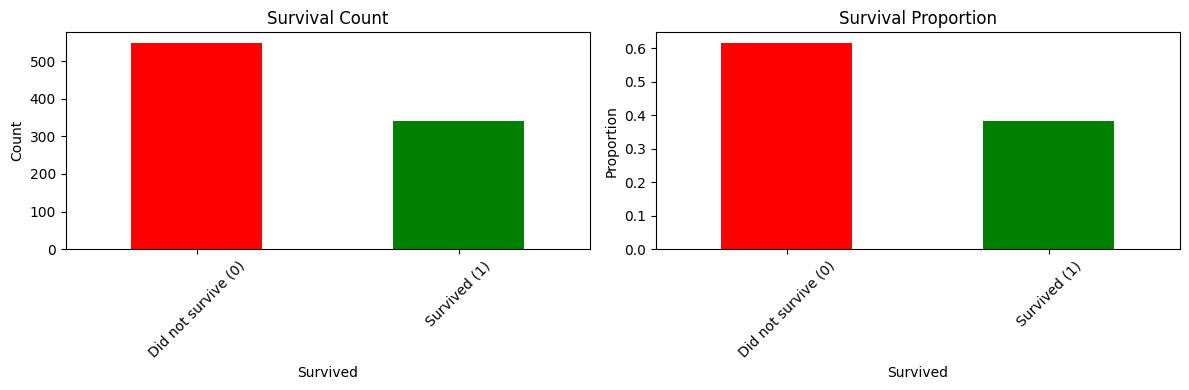

In [22]:
# Survival distribution
print("Survival Distribution:")
print(train_df['Survived'].value_counts())
print("\nSurvival Rate:", train_df['Survived'].mean())

# Visualize survival
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
train_df['Survived'].value_counts().plot(kind='bar', ax=axes[0], color=['red', 'green'])
axes[0].set_title('Survival Count')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['Did not survive (0)', 'Survived (1)'], rotation=45)

train_df['Survived'].value_counts(normalize=True).plot(kind='bar', ax=axes[1], color=['red', 'green'])
axes[1].set_title('Survival Proportion')
axes[1].set_ylabel('Proportion')
axes[1].set_xticklabels(['Did not survive (0)', 'Survived (1)'], rotation=45)
plt.tight_layout()
plt.show()

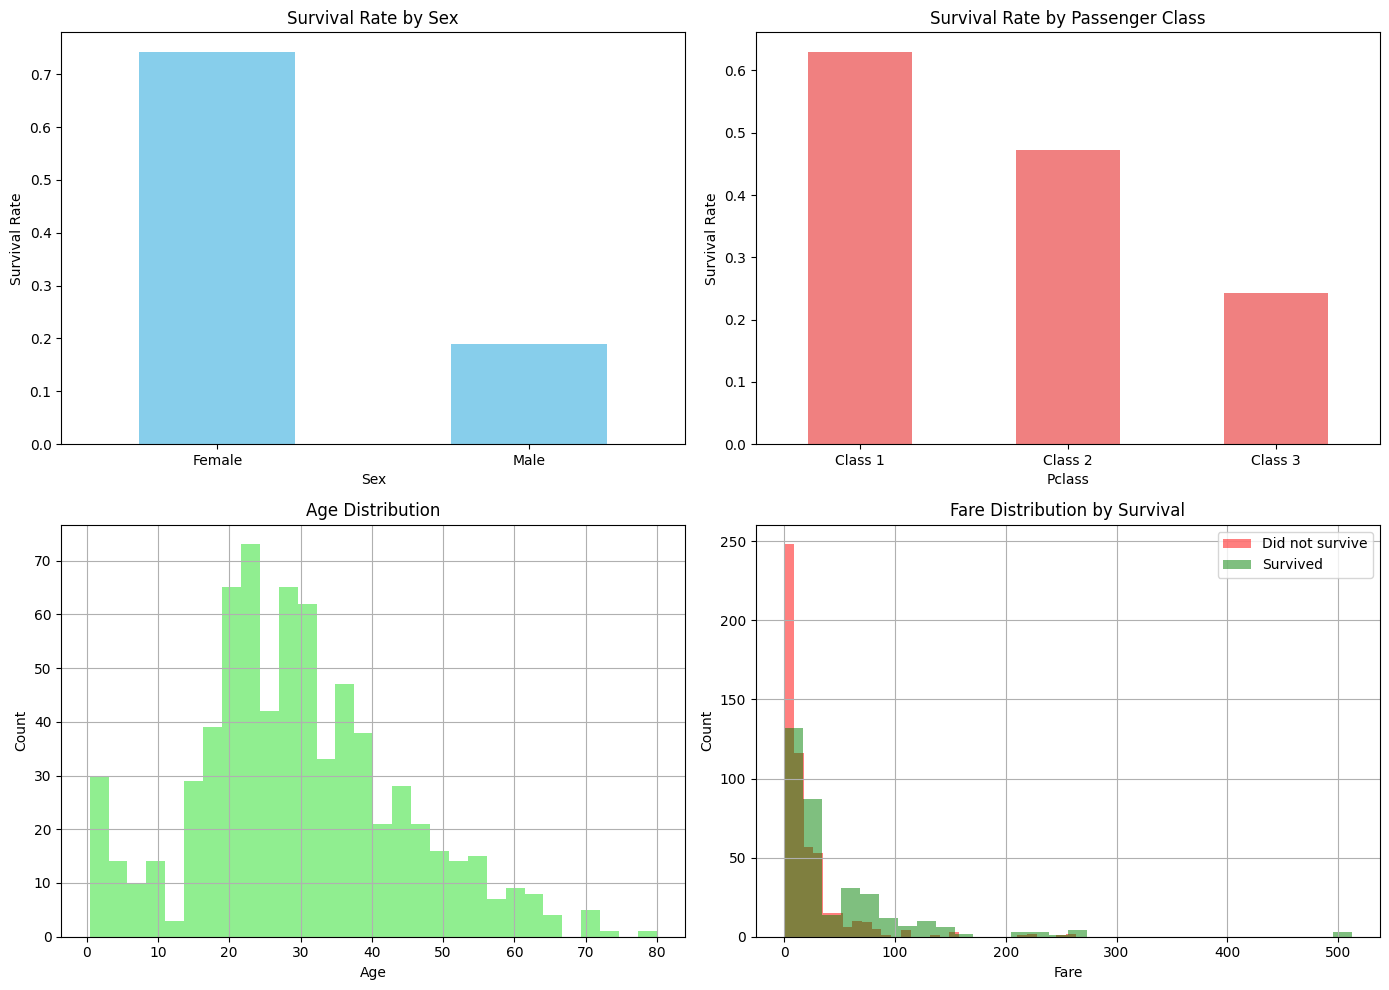

In [23]:
# Analyze survival by key features
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Survival by Sex
train_df.groupby('Sex')['Survived'].mean().plot(kind='bar', ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('Survival Rate by Sex')
axes[0, 0].set_ylabel('Survival Rate')
axes[0, 0].set_xticklabels(['Female', 'Male'], rotation=0)

# Survival by Pclass
train_df.groupby('Pclass')['Survived'].mean().plot(kind='bar', ax=axes[0, 1], color='lightcoral')
axes[0, 1].set_title('Survival Rate by Passenger Class')
axes[0, 1].set_ylabel('Survival Rate')
axes[0, 1].set_xticklabels(['Class 1', 'Class 2', 'Class 3'], rotation=0)

# Survival by Age
train_df['Age'].hist(bins=30, ax=axes[1, 0], color='lightgreen')
axes[1, 0].set_title('Age Distribution')
axes[1, 0].set_xlabel('Age')
axes[1, 0].set_ylabel('Count')

# Survival by Fare
train_df[train_df['Survived']==0]['Fare'].hist(bins=30, ax=axes[1, 1], alpha=0.5, label='Did not survive', color='red')
train_df[train_df['Survived']==1]['Fare'].hist(bins=30, ax=axes[1, 1], alpha=0.5, label='Survived', color='green')
axes[1, 1].set_title('Fare Distribution by Survival')
axes[1, 1].set_xlabel('Fare')
axes[1, 1].set_ylabel('Count')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

## 4. Data Preprocessing and Feature Engineering

In [24]:
# Create a copy of the dataframes for processing
train_data = train_df.copy()
test_data = test_df.copy()

# Store the PassengerId for submission
PassengerId = test_data['PassengerId'].copy()

# Combine train and test for preprocessing
all_data = pd.concat([train_data, test_data], ignore_index=True)

print("Combined data shape:", all_data.shape)

Combined data shape: (1309, 12)


In [25]:
# 1. Handle missing values

# Age - fill with median
all_data['Age'].fillna(all_data['Age'].median(), inplace=True)

# Embarked - fill with mode
all_data['Embarked'].fillna(all_data['Embarked'].mode()[0], inplace=True)

# Fare - fill with median
all_data['Fare'].fillna(all_data['Fare'].median(), inplace=True)

# Cabin - too many missing values, drop it
all_data.drop('Cabin', axis=1, inplace=True)

print("Missing values after handling:")
print(all_data.isnull().sum())

Missing values after handling:
PassengerId      0
Survived       418
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Embarked         0
dtype: int64


In [26]:
# 2. Create new features

# Family size
all_data['FamilySize'] = all_data['SibSp'] + all_data['Parch'] + 1

# Is alone
all_data['IsAlone'] = (all_data['FamilySize'] == 1).astype(int)

# Extract title from name
all_data['Title'] = all_data['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)

# Simplify titles
title_mapping = {
    'Mr': 'Mr',
    'Miss': 'Miss',
    'Mrs': 'Mrs',
    'Master': 'Master',
    'Dr': 'Rare',
    'Rev': 'Rare',
    'Col': 'Rare',
    'Major': 'Rare',
    'Mlle': 'Miss',
    'Countess': 'Rare',
    'Ms': 'Miss',
    'Mme': 'Mrs',
    'Don': 'Rare',
    'Lady': 'Rare',
    'Jonkheer': 'Rare',
    'Sir': 'Rare',
    'Capt': 'Rare'
}
all_data['Title'] = all_data['Title'].map(title_mapping)

# Age bins
all_data['AgeBins'] = pd.cut(all_data['Age'], bins=[0, 12, 20, 30, 40, 50, 60, 100], 
                               labels=['Child', 'Teen', 'Young Adult', 'Adult', 'Middle-aged', 'Senior', 'Elderly'])

# Fare bins
all_data['FareBins'] = pd.qcut(all_data['Fare'], q=4, labels=['Very Low', 'Low', 'Medium', 'High'], duplicates='drop')

print("New features created:")
print(all_data[['FamilySize', 'IsAlone', 'Title', 'AgeBins', 'FareBins']].head(10))

New features created:
   FamilySize  IsAlone   Title      AgeBins  FareBins
0           2        0      Mr  Young Adult  Very Low
1           2        0     Mrs        Adult      High
2           1        1    Miss  Young Adult       Low
3           2        0     Mrs        Adult      High
4           1        1      Mr        Adult       Low
5           1        1      Mr  Young Adult       Low
6           1        1      Mr       Senior      High
7           5        0  Master        Child    Medium
8           3        0     Mrs  Young Adult       Low
9           2        0     Mrs         Teen    Medium


In [27]:
# 3. Encode categorical variables

# Sex
all_data['Sex'] = all_data['Sex'].map({'male': 1, 'female': 0})

# Embarked
all_data['Embarked'] = all_data['Embarked'].map({'S': 1, 'C': 2, 'Q': 3})

# Title
title_encoding = {'Mr': 1, 'Miss': 2, 'Mrs': 3, 'Master': 4, 'Rare': 5}
all_data['Title'] = all_data['Title'].map(title_encoding)

# AgeBins
all_data['AgeBins'] = pd.Categorical(all_data['AgeBins'], 
                                      categories=['Child', 'Teen', 'Young Adult', 'Adult', 'Middle-aged', 'Senior', 'Elderly'],
                                      ordered=True)
all_data['AgeBins'] = all_data['AgeBins'].cat.codes + 1

# FareBins
all_data['FareBins'] = pd.Categorical(all_data['FareBins'],
                                       categories=['Very Low', 'Low', 'Medium', 'High'],
                                       ordered=True)
all_data['FareBins'] = all_data['FareBins'].cat.codes + 1

print("Categorical encoding complete")
print(all_data.head(10))

Categorical encoding complete
   PassengerId  Survived  Pclass  \
0            1       0.0       3   
1            2       1.0       1   
2            3       1.0       3   
3            4       1.0       1   
4            5       0.0       3   
5            6       0.0       3   
6            7       0.0       1   
7            8       0.0       3   
8            9       1.0       3   
9           10       1.0       2   

                                                Name  Sex   Age  SibSp  Parch  \
0                            Braund, Mr. Owen Harris    1  22.0      1      0   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...    0  38.0      1      0   
2                             Heikkinen, Miss. Laina    0  26.0      0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)    0  35.0      1      0   
4                           Allen, Mr. William Henry    1  35.0      0      0   
5                                   Moran, Mr. James    1  28.0      0      0   
6     

In [28]:
# 4. Drop unnecessary columns and prepare features

all_data.drop(['Name', 'Ticket'], axis=1, inplace=True)

# Separate train and test
train_processed = all_data[:len(train_data)]
test_processed = all_data[len(train_data):]

# Prepare X and y
X = train_processed.drop(['Survived', 'PassengerId'], axis=1)
y = train_processed['Survived']

X_test = test_processed.drop(['Survived', 'PassengerId'], axis=1)

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("Test features shape:", X_test.shape)
print("\nFeatures:")
print(X.columns.tolist())

Features shape: (891, 12)
Target shape: (891,)
Test features shape: (418, 12)

Features:
['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'FamilySize', 'IsAlone', 'Title', 'AgeBins', 'FareBins']


## 5. Train and Evaluate Models

In [29]:
# Split the training data
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]}")
print(f"Validation set size: {X_val.shape[0]}")

Training set size: 712
Validation set size: 179


In [30]:
# Train Random Forest model
print("Training Random Forest Classifier...")
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# Make predictions
rf_pred_train = rf_model.predict(X_train)
rf_pred_val = rf_model.predict(X_val)

# Evaluate
print(f"\nRandom Forest Results:")
print(f"Training Accuracy: {accuracy_score(y_train, rf_pred_train):.4f}")
print(f"Validation Accuracy: {accuracy_score(y_val, rf_pred_val):.4f}")
print(f"\nValidation Classification Report:")
print(classification_report(y_val, rf_pred_val))

Training Random Forest Classifier...

Random Forest Results:
Training Accuracy: 0.9368
Validation Accuracy: 0.8324

Validation Classification Report:
              precision    recall  f1-score   support

         0.0       0.84      0.89      0.86       105
         1.0       0.82      0.76      0.79        74

    accuracy                           0.83       179
   macro avg       0.83      0.82      0.82       179
weighted avg       0.83      0.83      0.83       179



In [31]:
# Train Logistic Regression model
print("Training Logistic Regression...")
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)

# Make predictions
lr_pred_train = lr_model.predict(X_train)
lr_pred_val = lr_model.predict(X_val)

# Evaluate
print(f"\nLogistic Regression Results:")
print(f"Training Accuracy: {accuracy_score(y_train, lr_pred_train):.4f}")
print(f"Validation Accuracy: {accuracy_score(y_val, lr_pred_val):.4f}")
print(f"\nValidation Classification Report:")
print(classification_report(y_val, lr_pred_val))

Training Logistic Regression...

Logistic Regression Results:
Training Accuracy: 0.8230
Validation Accuracy: 0.7877

Validation Classification Report:
              precision    recall  f1-score   support

         0.0       0.82      0.82      0.82       105
         1.0       0.74      0.74      0.74        74

    accuracy                           0.79       179
   macro avg       0.78      0.78      0.78       179
weighted avg       0.79      0.79      0.79       179



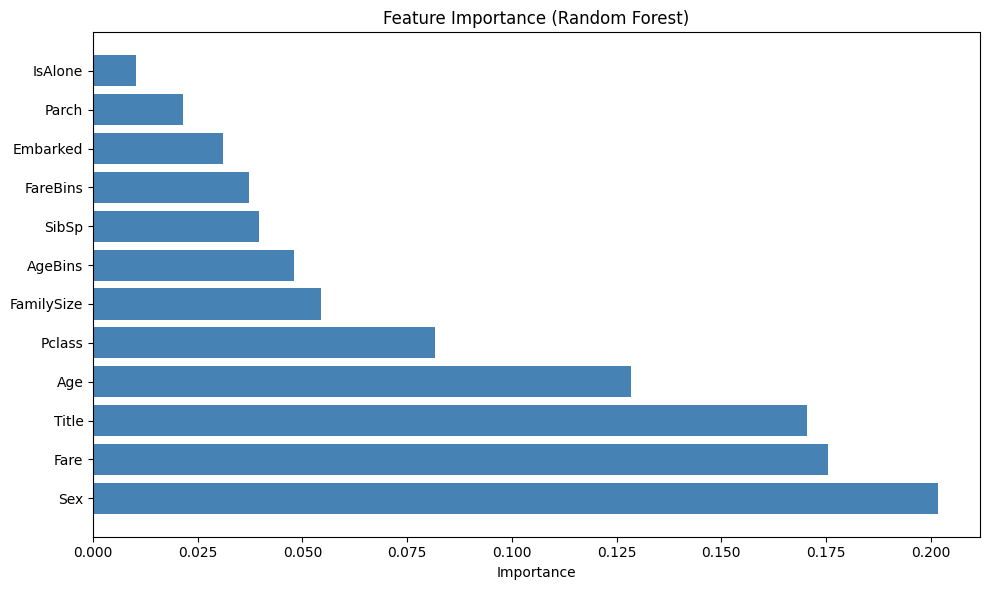

Top 10 Important Features:
       Feature  Importance
1          Sex    0.201696
5         Fare    0.175603
9        Title    0.170457
2          Age    0.128551
0       Pclass    0.081568
7   FamilySize    0.054519
10     AgeBins    0.047963
3        SibSp    0.039623
11    FareBins    0.037315
6     Embarked    0.030928


In [32]:
# Feature importance from Random Forest
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Feature'], feature_importance['Importance'], color='steelblue')
plt.xlabel('Importance')
plt.title('Feature Importance (Random Forest)')
plt.tight_layout()
plt.show()

print("Top 10 Important Features:")
print(feature_importance.head(10))

## 6. Make Predictions on Test Set

In [37]:
# Use the best model (Random Forest) for final predictions
print("Making predictions on test set...")
y_pred_final = rf_model.predict(X_test)

print(f"Predictions shape: {y_pred_final.shape}")
print(f"Unique predictions: {np.unique(y_pred_final)}")
print(f"Prediction distribution: {np.bincount(y_pred_final.astype(int))}")


Making predictions on test set...
Predictions shape: (418,)
Unique predictions: [0. 1.]
Prediction distribution: [272 146]


## 7. Create Submission File

In [35]:
# Create submission dataframe
submission = pd.DataFrame({
    'PassengerId': PassengerId,
    'Survived': y_pred_final
})

# Verify submission format
print(f"Submission shape: {submission.shape}")
print(f"Should have 418 rows: {len(submission) == 418}")
print(f"\nFirst few rows:")
print(submission.head())
print(f"\nLast few rows:")
print(submission.tail())

Submission shape: (418, 2)
Should have 418 rows: True

First few rows:
   PassengerId  Survived
0          892       0.0
1          893       0.0
2          894       0.0
3          895       0.0
4          896       1.0

Last few rows:
     PassengerId  Survived
413         1305       0.0
414         1306       1.0
415         1307       0.0
416         1308       0.0
417         1309       1.0


In [36]:
# Save submission to CSV
submission.to_csv('submission.csv', index=False)
print("Submission saved to 'submission.csv'")
print(f"\nFile can be uploaded to Kaggle competition!")

Submission saved to 'submission.csv'

File can be uploaded to Kaggle competition!


## 8. Next Steps to Improve Your Score

1. **Hyperparameter Tuning**: Use GridSearchCV or RandomizedSearchCV to optimize model parameters
2. **Ensemble Methods**: Combine multiple models using voting or stacking
3. **More Feature Engineering**: Create additional meaningful features
4. **Handle Class Imbalance**: Use techniques like SMOTE if needed
5. **Cross-Validation**: Use k-fold cross-validation for more robust evaluation
6. **Try Different Models**: Gradient Boosting, XGBoost, Neural Networks, etc.
7. **Check Kaggle Forums**: See what features and approaches top competitors are using